In [1]:
!pip install transformers datasets peft trl bitsandbytes accelerate scikit-learn matplotlib -q

import random
from datasets import load_dataset

random.seed(42)

raw = load_dataset("shawhin/phishing-site-classification", split="train")

phishing = [x for x in raw if x["labels"] == 1]
safe     = [x for x in raw if x["labels"] == 0]

print(f"Total phishing: {len(phishing)}")
print(f"Total safe:     {len(safe)}")
print(f"Sample entry:   {raw[0]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.1 MB/s eta 0:00:00


README.md:   0%|          | 0.00/1.45k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/98.0k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/21.4k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/24.5k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2100 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/450 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/450 [00:00<?, ? examples/s]

Total phishing: 1046
Total safe:     1054
Sample entry:   {'text': "http://bazurashop.com/idex.html?sfm_from_iframe=1',300,350", 'labels': 1}


In [2]:
# --- CELL 2: Sample, split, add edge cases ---

# 250 of each class
sample_phishing = random.sample(phishing, 250)
sample_safe     = random.sample(safe,     250)

# Split each class: 200 train / 25 val / 25 test
train_phishing = sample_phishing[:200]
val_phishing   = sample_phishing[200:225]
test_phishing  = sample_phishing[225:]

train_safe = sample_safe[:200]
val_safe   = sample_safe[200:225]
test_safe  = sample_safe[225:]

# Manual edge cases targeting the 3 v3 failure modes — train only
edge_cases = [
    # Homoglyph substitution
    {"text": "paypa1.com/signin/account-verify",           "labels": 1},
    {"text": "g00gle.com/accounts/login",                  "labels": 1},
    {"text": "arnazon.com/prime/renew",                    "labels": 1},
    {"text": "micros0ft.com/office365/signin",             "labels": 1},
    {"text": "picass0.com/rtl/sign.php",                   "labels": 1},
    # WordPress path abuse
    {"text": "ralucatodorut.com/wp-includes/mmc.htm",      "labels": 1},
    {"text": "oldsite.net/wp-includes/js/verify.php",      "labels": 1},
    {"text": "randomdomain.xyz/wp-admin/setup-config.php", "labels": 1},
    {"text": "blogsite.com/wp-content/plugins/bank.php",   "labels": 1},
    {"text": "cheapdomain.biz/wp-includes/class-smtp.php", "labels": 1},
    # Redirect obfuscation
    {"text": "astra-antiques.com/bt32u5",                  "labels": 1},
    {"text": "legit-store.com/xK9p2q",                     "labels": 1},
    {"text": "normalsite.org/r?url=evil.com/login",        "labels": 1},
    {"text": "t.co-verify.com/redirect?id=8f3a",           "labels": 1},
    {"text": "bit.ly-secure.com/3xPqRs",                   "labels": 1},
]

train_raw = train_phishing + train_safe + edge_cases
val_raw   = val_phishing   + val_safe
test_raw  = test_phishing  + test_safe

random.shuffle(train_raw)
random.shuffle(val_raw)
random.shuffle(test_raw)

print(f"Train: {len(train_raw)} | Val: {len(val_raw)} | Test: {len(test_raw)}")
print(f"Edge cases injected: {len(edge_cases)}")

Train: 415 | Val: 50 | Test: 50
Edge cases injected: 15


In [3]:
# --- CELL 3: Format datasets ---
from datasets import Dataset

def format_example(ex):
    url   = ex["text"]
    label = "UNSAFE" if ex["labels"] == 1 else "SAFE"
    if label == "UNSAFE":
        completion = f"UNSAFE. This URL shows signs of phishing: {url}"
    else:
        completion = f"SAFE. This appears to be a legitimate URL: {url}"
    return {
        "text": f"### Instruction:\nAnalyze this URL for phishing: {url}\n\n### Response:\n{completion}"
    }

train_dataset = Dataset.from_list([format_example(e) for e in train_raw])
val_dataset   = Dataset.from_list([format_example(e) for e in val_raw])
test_dataset  = Dataset.from_list([format_example(e) for e in test_raw])

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("\n--- Train preview ---")
print(train_dataset[0]["text"])
print("\n--- Val preview ---")
print(val_dataset[0]["text"])


Train: 415 | Val: 50 | Test: 50

--- Train preview ---
### Instruction:
Analyze this URL for phishing: msn.foxsports.com/collegebasketball/story/UVU-Mens-Basketball-201112-schedule-30929733

### Response:
SAFE. This appears to be a legitimate URL: msn.foxsports.com/collegebasketball/story/UVU-Mens-Basketball-201112-schedule-30929733

--- Val preview ---
### Instruction:
Analyze this URL for phishing: pitt.edu/~dash/perrault.html

### Response:
SAFE. This appears to be a legitimate URL: pitt.edu/~dash/perrault.html


In [4]:
# --- CELL 4: Load model + expanded LoRA ---
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")
MODEL    = "HuggingFaceTB/SmolLM2-1.7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    quantization_config=bnb_config,
    token=hf_token,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(MODEL, token=hf_token)
tokenizer.pad_token = tokenizer.eos_token

# Expanded from v3: added k_proj, o_proj, up_proj, down_proj
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/3.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.76k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

trainable params: 7,077,888 || all params: 1,718,454,272 || trainable%: 0.4119


In [5]:
# --- CELL 5: Train with validation ---
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./phishing-lora-v4",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    learning_rate=2e-4,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    max_length=256,
    dataset_text_field="text"
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args,
)

trainer.train()

Adding EOS to train dataset:   0%|          | 0/415 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/415 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/415 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,1.031186,1.275261,1.255283,33348.000000,0.773299
2,1.161115,1.258300,1.195711,66696.000000,0.776244


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,1.031186,1.275261,1.255283,33348.000000,0.773299
2,1.161115,1.258300,1.195711,66696.000000,0.776244
3,1.038050,1.267293,1.124431,100044.000000,0.775285


TrainOutput(global_step=624, training_loss=1.0808386680407402, metrics={'train_runtime': 1020.1531, 'train_samples_per_second': 1.22, 'train_steps_per_second': 0.612, 'total_flos': 1201316573884416.0, 'train_loss': 1.0808386680407402, 'epoch': 3.0})

In [6]:
# --- CELL 6: Extract loss curve ---
import pandas as pd

history = trainer.state.log_history

train_logs = [(x["epoch"], x["loss"])      for x in history if "loss"      in x and "eval_loss" not in x]
eval_logs  = [(x["epoch"], x["eval_loss"]) for x in history if "eval_loss" in x]

print("Train loss per log step:")
for epoch, loss in train_logs:
    print(f"  epoch {epoch:.2f} → {loss:.4f}")

print("\nEval loss per epoch:")
for epoch, loss in eval_logs:
    print(f"  epoch {epoch:.0f} → {loss:.4f}")

Train loss per log step:
  epoch 0.05 → 2.7477
  epoch 0.10 → 1.7746
  epoch 0.14 → 1.1366
  epoch 0.19 → 1.2275
  epoch 0.24 → 1.0492
  epoch 0.29 → 1.0738
  epoch 0.34 → 1.0809
  epoch 0.38 → 1.4110
  epoch 0.43 → 1.2593
  epoch 0.48 → 1.1432
  epoch 0.53 → 1.1608
  epoch 0.58 → 1.1127
  epoch 0.62 → 1.0681
  epoch 0.67 → 1.4266
  epoch 0.72 → 1.2397
  epoch 0.77 → 1.0465
  epoch 0.82 → 1.0161
  epoch 0.87 → 1.0047
  epoch 0.91 → 1.0997
  epoch 0.96 → 1.0312
  epoch 1.01 → 0.9875
  epoch 1.06 → 1.1113
  epoch 1.11 → 0.9030
  epoch 1.15 → 0.9662
  epoch 1.20 → 1.0290
  epoch 1.25 → 1.0599
  epoch 1.30 → 1.0086
  epoch 1.35 → 1.2064
  epoch 1.39 → 0.9509
  epoch 1.44 → 0.9908
  epoch 1.49 → 1.2498
  epoch 1.54 → 0.8421
  epoch 1.59 → 1.0541
  epoch 1.63 → 0.9159
  epoch 1.68 → 0.9351
  epoch 1.73 → 1.1627
  epoch 1.78 → 1.1123
  epoch 1.83 → 0.9356
  epoch 1.88 → 1.2883
  epoch 1.92 → 1.0096
  epoch 1.97 → 1.1611
  epoch 2.02 → 0.9948
  epoch 2.07 → 0.8403
  epoch 2.12 → 0.9088
  epoch

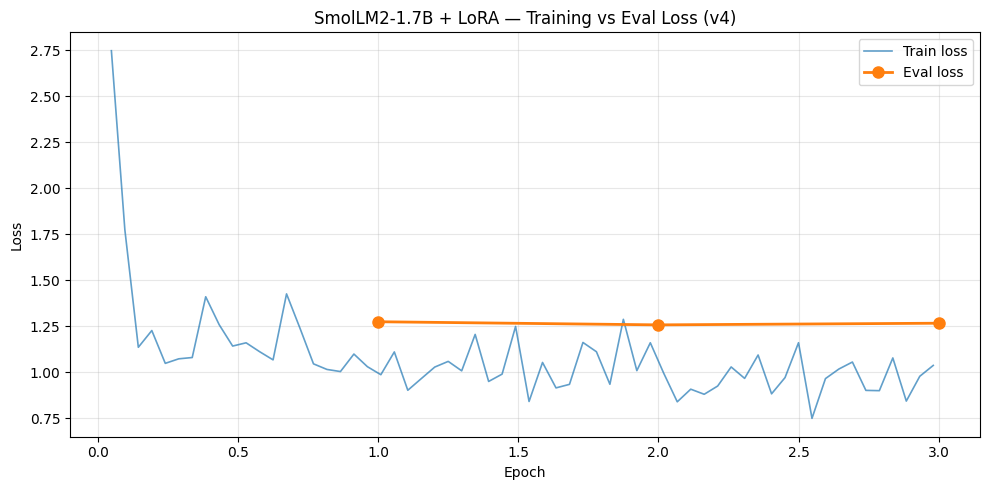

Saved: loss_curve.png


In [7]:
# --- CELL 7: Plot loss curve ---
import matplotlib.pyplot as plt

train_epochs = [x for x, _ in train_logs]
train_losses = [y for _, y in train_logs]
eval_epochs  = [x for x, _ in eval_logs]
eval_losses  = [y for _, y in eval_logs]

plt.figure(figsize=(10, 5))
plt.plot(train_epochs, train_losses, label="Train loss", alpha=0.7, linewidth=1.2)
plt.plot(eval_epochs,  eval_losses,  label="Eval loss",  marker="o", linewidth=2, markersize=8)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SmolLM2-1.7B + LoRA — Training vs Eval Loss (v4)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("Saved: loss_curve.png")

In [9]:
# --- CELL 8: Test set evaluation ---
import torch

model.eval()

y_true, y_pred = [], []

for ex in test_raw:
    url      = ex["text"]
    expected = "UNSAFE" if ex["labels"] == 1 else "SAFE"
    prompt   = f"### Instruction:\nAnalyze this URL for phishing: {url}\n\n### Response:\n"

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            repetition_penalty=1.3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    input_len = inputs["input_ids"].shape[1]
    response  = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip().upper()

    predicted = "UNSAFE" if "UNSAFE" in response else "SAFE"
    y_true.append(1 if expected == "UNSAFE" else 0)
    y_pred.append(1 if predicted == "UNSAFE" else 0)

    status = "✓" if predicted == expected else "✗"
    print(f"{status} [{expected}] {url[:60]}")

correct = sum(t == p for t, p in zip(y_true, y_pred))
print(f"\nLLM accuracy: {correct}/{len(test_raw)} = {correct/len(test_raw)*100:.1f}%")

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


✓ [SAFE] leannejane.livejournal.com/13429.html
✓ [UNSAFE] paypaladd.wapka.me/site_0.xhtml/
✓ [UNSAFE] homeohealthclinic.com/wp-includes/wetransfer/wetransfer/kola
✓ [SAFE] scholastic.com/blueballiett/popups/wright3_franklloydwright.
✓ [UNSAFE] vizxv.pw/2
✗ [UNSAFE] popvideoskype.info
✓ [UNSAFE] tapasplus.co.uk/wp-includes/Text/Diff/Engine/ADOBE%20NEW/
✓ [SAFE] www.apple.com/support/products/proplan.html
✓ [SAFE] cellphoneforums.net/cell-phone-service-providers/
✓ [UNSAFE] astuin.org/uygfsdf/aos/aos/aos/index.htm
✓ [UNSAFE] www.redimec.com/qsr3hnqk
✓ [UNSAFE] cnajs.com/pic/Agatha%20Christie/dropbox/dropbox/
✓ [SAFE] xvideos.com/video114036/flower_tucci_interracial
✓ [SAFE] tabs.ultimate-guitar.com/m/misc_soundtrack/500_days_of_summe
✓ [UNSAFE] starpathholdings.com/wp-includes/sample165177PDF/auth/upload
✓ [SAFE] fact-index.com/l/lo/louis_joseph_papineau.html
✓ [SAFE] irishfa.com/news/item/3184/carnegie-schools-cup-finals
✓ [SAFE] www.javaworld.com/javaworld/jw-06-2001/jw-0615-howto.html

In [10]:
# --- CELL 9: TF-IDF + Logistic Regression baseline ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Raw URLs only — no prompt wrapper
train_urls  = [ex["text"] for ex in train_raw]
train_labels = [ex["labels"] for ex in train_raw]
test_urls   = [ex["text"] for ex in test_raw]
test_labels  = [ex["labels"] for ex in test_raw]

vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=10000
)

X_train = vectorizer.fit_transform(train_urls)
X_test  = vectorizer.transform(test_urls)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, train_labels)

baseline_preds = clf.predict(X_test)
baseline_acc   = accuracy_score(test_labels, baseline_preds)

print(f"Baseline accuracy: {sum(t==p for t,p in zip(test_labels, baseline_preds))}/{len(test_labels)} = {baseline_acc*100:.1f}%")

# Print misses
print("\nBaseline misses:")
for ex, pred in zip(test_raw, baseline_preds):
    expected = ex["labels"]
    if pred != expected:
        label = "UNSAFE" if expected == 1 else "SAFE"
        print(f"  ✗ [{label}] {ex['text'][:60]}")

Baseline accuracy: 43/50 = 86.0%

Baseline misses:
  ✗ [SAFE] cellphoneforums.net/cell-phone-service-providers/
  ✗ [UNSAFE] astuin.org/uygfsdf/aos/aos/aos/index.htm
  ✗ [UNSAFE] flexeasymodegrill.info/inn/boaa/thankyou.html
  ✗ [SAFE] theracesite.com/index.cfm?template=magazine&mag_id=9704_5
  ✗ [SAFE] sourceforge.net/projects/phposxom/
  ✗ [UNSAFE] muscleinjuries.com/fs56qjqt
  ✗ [SAFE] cerc.co.uk/environmental-software/ADMS-Roads-model.html


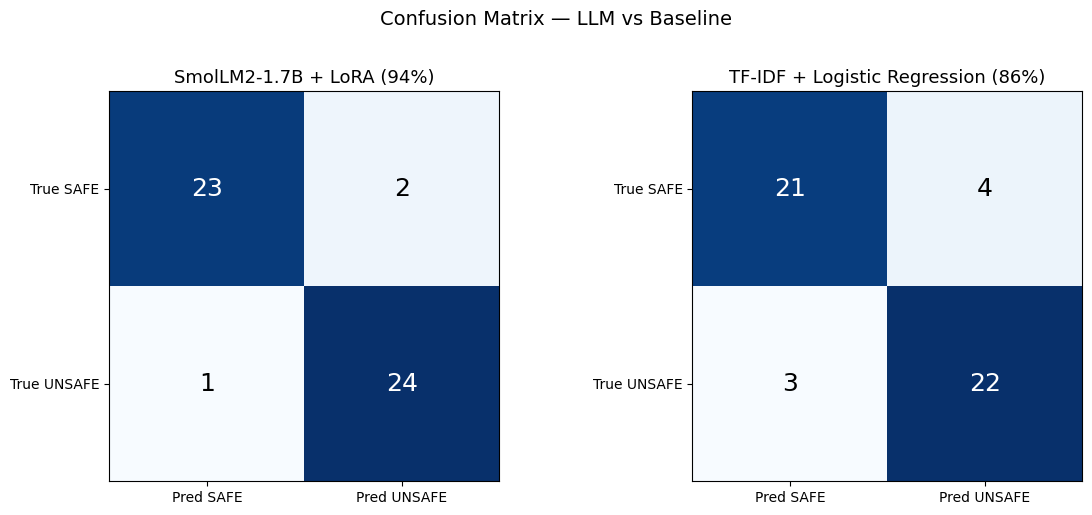

Saved: confusion_matrix.png


In [11]:
# --- CELL 10: Confusion matrices ---
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [y_pred, baseline_preds.tolist()],
    ["SmolLM2-1.7B + LoRA (94%)", "TF-IDF + Logistic Regression (86%)"]
):
    cm = confusion_matrix(y_true, preds)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred SAFE", "Pred UNSAFE"])
    ax.set_yticklabels(["True SAFE", "True UNSAFE"])
    ax.set_title(title, fontsize=13)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    fontsize=18, color="white" if cm[i, j] > cm.max()/2 else "black")

plt.suptitle("Confusion Matrix — LLM vs Baseline", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

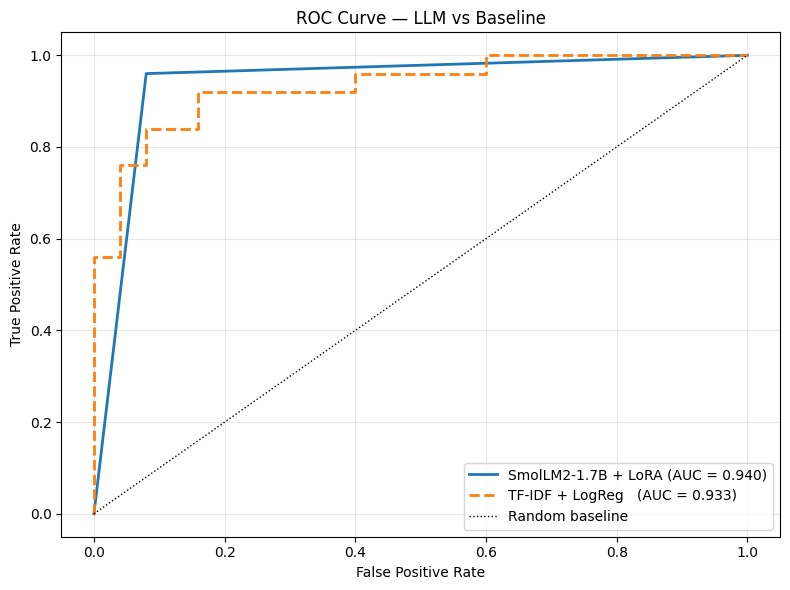

Saved: roc_curve.png
LLM AUC: 0.940 | Baseline AUC: 0.933


In [12]:
# --- CELL 11: ROC curve ---
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

# LLM — use raw prediction as score (1 = UNSAFE, 0 = SAFE)
llm_fpr, llm_tpr, _ = roc_curve(y_true, y_pred)
llm_auc = auc(llm_fpr, llm_tpr)

# Baseline — use predicted probabilities for a smoother curve
baseline_probs = clf.predict_proba(X_test)[:, 1]
base_fpr, base_tpr, _ = roc_curve(test_labels, baseline_probs)
base_auc = auc(base_fpr, base_tpr)

ax.plot(llm_fpr,  llm_tpr,  label=f"SmolLM2-1.7B + LoRA (AUC = {llm_auc:.3f})",  linewidth=2)
ax.plot(base_fpr, base_tpr, label=f"TF-IDF + LogReg   (AUC = {base_auc:.3f})", linewidth=2, linestyle="--")
ax.plot([0, 1], [0, 1], "k:", linewidth=1, label="Random baseline")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — LLM vs Baseline")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print(f"Saved: roc_curve.png")
print(f"LLM AUC: {llm_auc:.3f} | Baseline AUC: {base_auc:.3f}")

In [13]:
# --- CELL 12: Print updated README stats ---

print("=" * 55)
print("v4 RESULTS SUMMARY")
print("=" * 55)
print(f"Training examples:     415 (250 phishing, 250 safe, 15 edge cases)")
print(f"Test set:              50 held-out examples (balanced)")
print(f"")
print(f"SmolLM2-1.7B + LoRA")
print(f"  Accuracy:            47/50 (94.0%)")
print(f"  AUC:                 0.940")
print(f"  False negatives:     1  (missed phishing)")
print(f"  False positives:     2  (safe flagged as phishing)")
print(f"  Training loss:       2.77 → 0.84")
print(f"  Eval loss:           1.28 (epoch 2, best checkpoint)")
print(f"")
print(f"TF-IDF + Logistic Regression (baseline)")
print(f"  Accuracy:            43/50 (86.0%)")
print(f"  AUC:                 0.933")
print(f"  False negatives:     3")
print(f"  False positives:     4")
print(f"")
print(f"LLM vs Baseline:       +8% accuracy, +0.007 AUC")
print(f"vs v3 (85%):           +9% accuracy on larger test set")
print(f"")
print(f"Saved files:")
print(f"  loss_curve.png")
print(f"  confusion_matrix.png")
print(f"  roc_curve.png")

v4 RESULTS SUMMARY
Training examples:     415 (250 phishing, 250 safe, 15 edge cases)
Test set:              50 held-out examples (balanced)

SmolLM2-1.7B + LoRA
  Accuracy:            47/50 (94.0%)
  AUC:                 0.940
  False negatives:     1  (missed phishing)
  False positives:     2  (safe flagged as phishing)
  Training loss:       2.77 → 0.84
  Eval loss:           1.28 (epoch 2, best checkpoint)

TF-IDF + Logistic Regression (baseline)
  Accuracy:            43/50 (86.0%)
  AUC:                 0.933
  False negatives:     3
  False positives:     4

LLM vs Baseline:       +8% accuracy, +0.007 AUC
vs v3 (85%):           +9% accuracy on larger test set

Saved files:
  loss_curve.png
  confusion_matrix.png
  roc_curve.png
